# Feature Engineering

Machine Learning models cannot read English words. They need numbers. Here, we use TF-IDF to convert cleaned text into a matrix of numerical features.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import show_top_ngrams_by_class, add_basic_meta_features, plot_dimensionality_reduction, save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


load cleaned text

In [3]:
processed_train = pd.read_csv(r'data/processed/processed_train.csv', dtype=str, quoting=0)
processed_train.head()

,review_target,review_title,review_content,char_count,word_count,review_cleaned
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,dx6340 year love picture good 35m easy use unl...
1,1,not so great,I'm using this book in an introductory organic...,570,88,using book introductory organic spectroscopy c...
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,read first chapter bombarded reference 199 end...
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,feel cheaply made battery contact rusted soon ...
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,love sheet sleek smooth really cool feel perfe...


In [4]:
processed_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 79972 entries, 0 to 79971
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   review_target   79972 non-null  str  
 1   review_title    79972 non-null  str  
 2   review_content  79972 non-null  str  
 3   char_count      79972 non-null  str  
 4   word_count      79972 non-null  str  
 5   review_cleaned  79972 non-null  str  
dtypes: str(6)
memory usage: 3.7 MB


top unigrams, bigrams, and trigrams per class

In [5]:
feat_eng_train = processed_train.copy()


Top unigrams for class 1 and 2 of cleaned review

--- Top unigrams for class 1 ---
[('book', np.int64(22267)), ('like', np.int64(11613)), ('time', np.int64(9543)), ('good', np.int64(8317)), ('movie', np.int64(7780)), ('read', np.int64(6545)), ('product', np.int64(6364)), ('work', np.int64(6202)), ('really', np.int64(5892)), ('buy', np.int64(5447)), ('make', np.int64(5187)), ('money', np.int64(5070)), ('better', np.int64(5002)), ('bought', np.int64(4836)), ('great', np.int64(4585))]



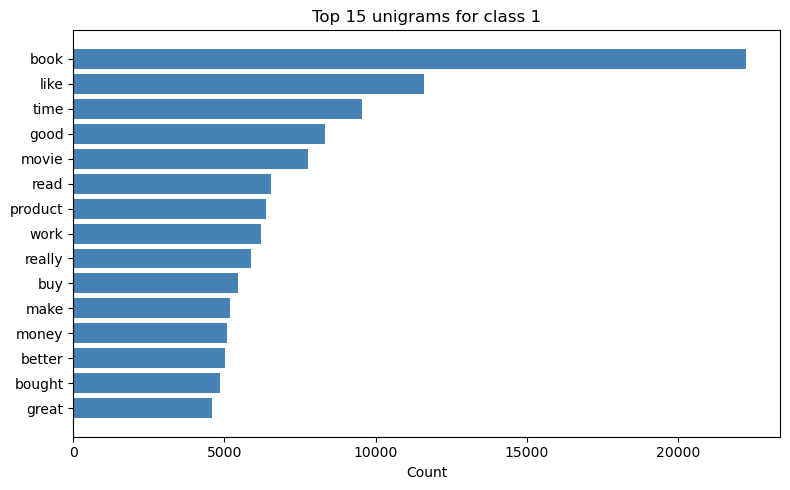

--- Top unigrams for class 2 ---
[('book', np.int64(23178)), ('great', np.int64(13512)), ('like', np.int64(10799)), ('good', np.int64(10496)), ('time', np.int64(8353)), ('read', np.int64(8136)), ('love', np.int64(7968)), ('movie', np.int64(6466)), ('really', np.int64(6304)), ('album', np.int64(5557)), ('cd', np.int64(5496)), ('work', np.int64(5403)), ('year', np.int64(5287)), ('make', np.int64(5260)), ('best', np.int64(5110))]



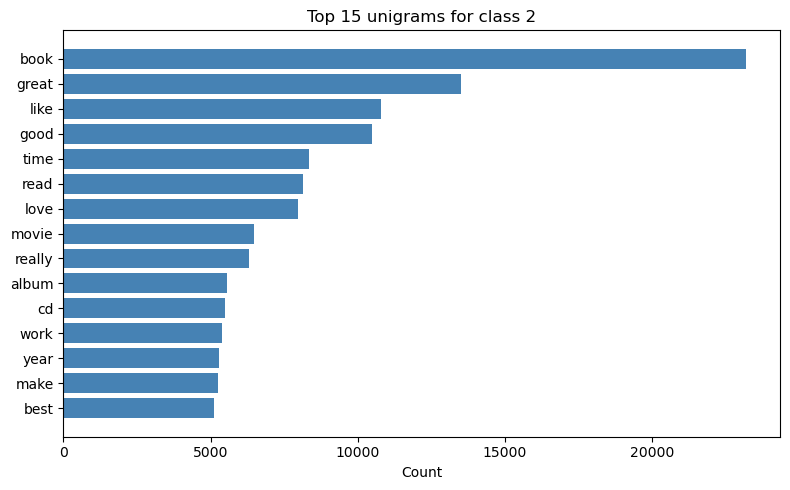

{'1': {(1, 1): [('book', np.int64(22267)),
   ('like', np.int64(11613)),
   ('time', np.int64(9543)),
   ('good', np.int64(8317)),
   ('movie', np.int64(7780)),
   ('read', np.int64(6545)),
   ('product', np.int64(6364)),
   ('work', np.int64(6202)),
   ('really', np.int64(5892)),
   ('buy', np.int64(5447)),
   ('make', np.int64(5187)),
   ('money', np.int64(5070)),
   ('better', np.int64(5002)),
   ('bought', np.int64(4836)),
   ('great', np.int64(4585))]},
 '2': {(1, 1): [('book', np.int64(23178)),
   ('great', np.int64(13512)),
   ('like', np.int64(10799)),
   ('good', np.int64(10496)),
   ('time', np.int64(8353)),
   ('read', np.int64(8136)),
   ('love', np.int64(7968)),
   ('movie', np.int64(6466)),
   ('really', np.int64(6304)),
   ('album', np.int64(5557)),
   ('cd', np.int64(5496)),
   ('work', np.int64(5403)),
   ('year', np.int64(5287)),
   ('make', np.int64(5260)),
   ('best', np.int64(5110))]}}

In [6]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_cleaned', ngram_ranges=(1, 1), top_k=15)


Top bigrams for class 1 and 2 of cleaned review

--- Top bigrams for class 1 ---
[('waste money', np.int64(1455)), ('read book', np.int64(983)), ('waste time', np.int64(928)), ('year old', np.int64(898)), ('look like', np.int64(688)), ('save money', np.int64(655)), ('sound like', np.int64(636)), ('book read', np.int64(618)), ('year ago', np.int64(497)), ('customer service', np.int64(464)), ('reading book', np.int64(425)), ('read review', np.int64(378))]



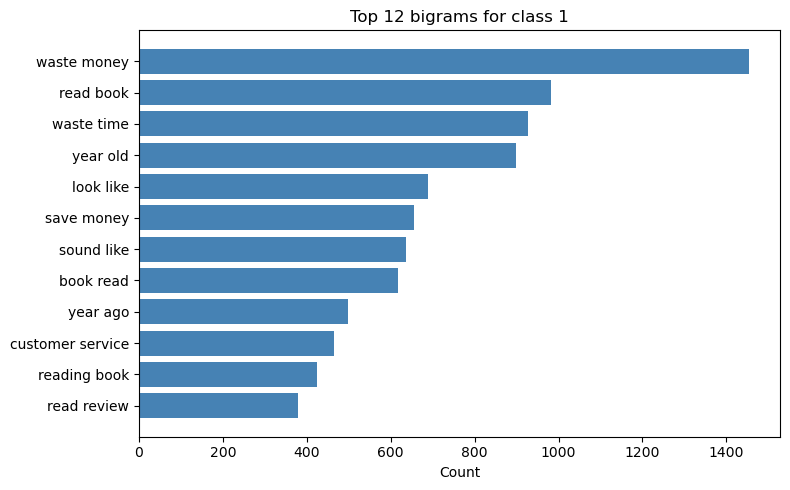

--- Top bigrams for class 2 ---
[('read book', np.int64(1421)), ('highly recommend', np.int64(1114)), ('year old', np.int64(1071)), ('book read', np.int64(914)), ('year ago', np.int64(690)), ('recommend book', np.int64(604)), ('great book', np.int64(558)), ('work great', np.int64(554)), ('long time', np.int64(534)), ('reading book', np.int64(511)), ('book great', np.int64(487)), ('highly recommended', np.int64(473))]



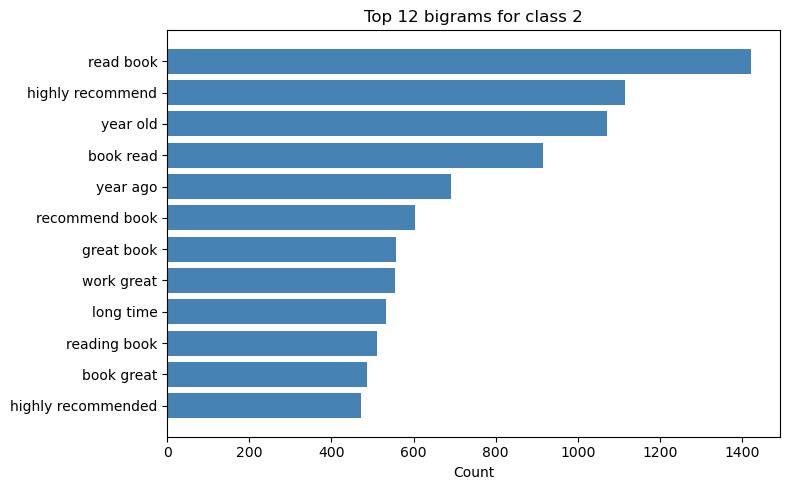

{'1': {(2, 2): [('waste money', np.int64(1455)),
   ('read book', np.int64(983)),
   ('waste time', np.int64(928)),
   ('year old', np.int64(898)),
   ('look like', np.int64(688)),
   ('save money', np.int64(655)),
   ('sound like', np.int64(636)),
   ('book read', np.int64(618)),
   ('year ago', np.int64(497)),
   ('customer service', np.int64(464)),
   ('reading book', np.int64(425)),
   ('read review', np.int64(378))]},
 '2': {(2, 2): [('read book', np.int64(1421)),
   ('highly recommend', np.int64(1114)),
   ('year old', np.int64(1071)),
   ('book read', np.int64(914)),
   ('year ago', np.int64(690)),
   ('recommend book', np.int64(604)),
   ('great book', np.int64(558)),
   ('work great', np.int64(554)),
   ('long time', np.int64(534)),
   ('reading book', np.int64(511)),
   ('book great', np.int64(487)),
   ('highly recommended', np.int64(473))]}}

In [7]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_cleaned', ngram_ranges=(2, 2), top_k=12)


Top trigrams for class 1 and 2 of cleaned review

--- Top 3-3grams for class 1 ---
[('waste time money', np.int64(236)), ('save money buy', np.int64(112)), ('worst book read', np.int64(87)), ('total waste money', np.int64(86)), ('complete waste money', np.int64(79)), ('worst movie seen', np.int64(74)), ('waste money time', np.int64(67)), ('complete waste time', np.int64(57)), ('year old son', np.int64(56)), ('hard earned money', np.int64(54)), ('really looking forward', np.int64(53)), ('book read like', np.int64(51))]



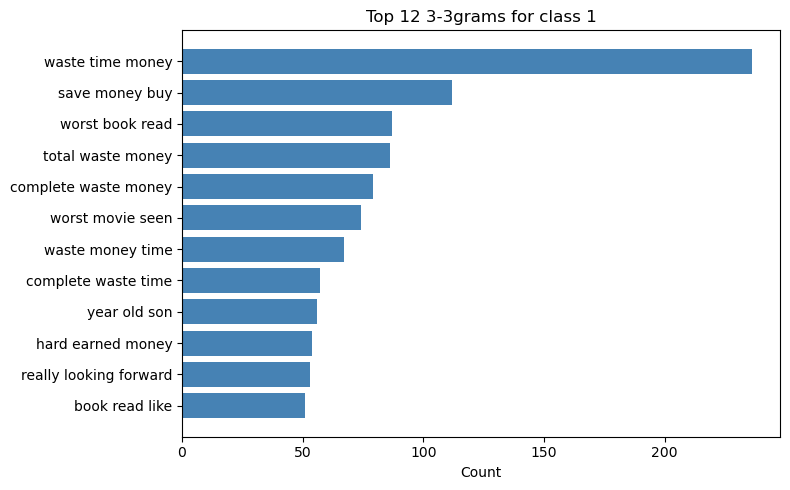

--- Top 3-3grams for class 2 ---
[('highly recommend book', np.int64(195)), ('best book read', np.int64(133)), ('year old son', np.int64(111)), ('year old daughter', np.int64(79)), ('book easy read', np.int64(70)), ('really enjoyed book', np.int64(68)), ('highly recommend product', np.int64(61)), ('book year ago', np.int64(56)), ('year old love', np.int64(54)), ('book read book', np.int64(46)), ('enjoyed reading book', np.int64(46)), ('couple year ago', np.int64(43))]



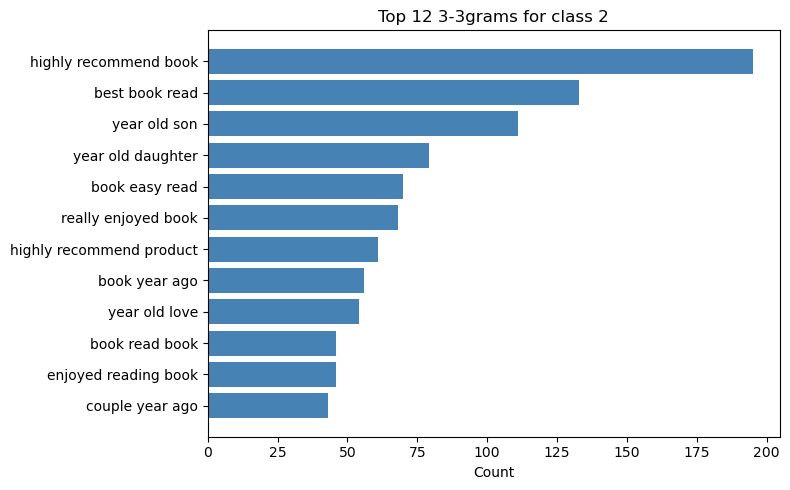

{'1': {(3, 3): [('waste time money', np.int64(236)),
   ('save money buy', np.int64(112)),
   ('worst book read', np.int64(87)),
   ('total waste money', np.int64(86)),
   ('complete waste money', np.int64(79)),
   ('worst movie seen', np.int64(74)),
   ('waste money time', np.int64(67)),
   ('complete waste time', np.int64(57)),
   ('year old son', np.int64(56)),
   ('hard earned money', np.int64(54)),
   ('really looking forward', np.int64(53)),
   ('book read like', np.int64(51))]},
 '2': {(3, 3): [('highly recommend book', np.int64(195)),
   ('best book read', np.int64(133)),
   ('year old son', np.int64(111)),
   ('year old daughter', np.int64(79)),
   ('book easy read', np.int64(70)),
   ('really enjoyed book', np.int64(68)),
   ('highly recommend product', np.int64(61)),
   ('book year ago', np.int64(56)),
   ('year old love', np.int64(54)),
   ('book read book', np.int64(46)),
   ('enjoyed reading book', np.int64(46)),
   ('couple year ago', np.int64(43))]}}

In [8]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_cleaned', ngram_ranges=(3, 3), top_k=12)


Basic meta-features

In [9]:
feat_eng_train = add_basic_meta_features(feat_eng_train, text_col='review_content')
feat_eng_train

,review_target,review_title,review_content,char_count,word_count,review_cleaned,exclamation_count,question_count,punctuation_count,avg_word_length,uppercase_count,uppercase_ratio
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,dx6340 year love picture good 35m easy use unl...,0,0,14,4.435185,455,0.776451
1,1,not so great,I'm using this book in an introductory organic...,570,88,using book introductory organic spectroscopy c...,0,0,12,5.488636,4,0.007018
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,read first chapter bombarded reference 199 end...,0,0,5,4.375000,3,0.014019
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,feel cheaply made battery contact rusted soon ...,0,0,2,4.705882,2,0.010363
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,love sheet sleek smooth really cool feel perfe...,1,0,9,4.236842,4,0.020202
...,...,...,...,...,...,...,...,...,...,...,...,...
79967,1,A Half-Step Above Johnny Tremain,Do not mistake this book for quality adult fic...,694,120,not mistake book quality adult fiction spoonfu...,0,0,21,4.791667,16,0.023055
79968,2,pretty good game,this grand theft auto is very fun like all the...,518,98,grand theft auto very fun like others played b...,0,0,11,4.295918,0,0.000000
79969,2,WORTH LOOKING FOR,"Easy, fun, and addictive.And the soundtrack is...",160,26,easy fun addictive soundtrack like nothing hea...,1,0,9,5.192308,4,0.025000
79970,1,Part was not what ordered,You will not receive Supco part. The prongs ar...,142,28,not receive supco part prong different wire no...,0,0,3,4.107143,4,0.028169


correlation with target

Convert target to numeric for correlation (fall back to category codes)

In [ ]:
meta_cols= ['char_count', 'word_count', 'exclamation_count', 'question_count', 'punctuation_count', 'avg_word_length', 'uppercase_count', 'uppercase_ratio']
try:
    target_numeric = pd.to_numeric(feat_eng_train['review_target'], errors='coerce')
    if target_numeric.isna().sum() > len(target_numeric) * 0.5:
        target_numeric = feat_eng_train['review_target'].astype('category').cat.codes
    else:
        target_numeric = target_numeric.fillna(0)
except Exception:
    target_numeric = feat_eng_train['review_target'].astype('category').cat.codes
    
corrs = {col: pd.Series(feat_eng_train[col]).corr(target_numeric) for col in meta_cols}
corr_series = pd.Series(corrs).sort_values(ascending=False)
print('Correlations between meta-features and target:')
print(corr_series)


Correlations between meta-features and target:
exclamation_count    0.027933
avg_word_length      0.013098
uppercase_ratio     -0.000912
uppercase_count     -0.019469
char_count          -0.067318
punctuation_count   -0.069328
word_count          -0.071107
question_count      -0.090043
dtype: float64


`question_count (-0.190)`: `negative correlation`.    
This means that the `more questions` there are in the review, the more likely it is that the review will be `negative` (close to 0).

`word_count (-0.122)` & `char_count (-0.116)`: `negative correlation`.   
The `longer the review`, the more likely it is to be `negative`.

`uppercase_ratio (0.111)` & `uppercase_count (0.084)`: `positive correlation` (positive but weak).    
The `more capital letters`, the `more positive` the review tends to be.

`avg_word_length (-0.006)` & `punctuation_count (-0.018)`: These numbers are very close to zero.    
This means that these `features are almost useless` and do `not influence` whether the `review is positive or negative`.

Visualize separability using dimensionality reduction (PCA or TSNE)

In [11]:
tfidf_train = TfidfVectorizer(ngram_range=(1,2), max_features=20000, stop_words='english')
tfidf_train = tfidf_train.fit_transform(feat_eng_train['review_cleaned'].astype(str))
print('TF-IDF shape:', tfidf_train.shape)

TF-IDF shape: (79972, 20000)


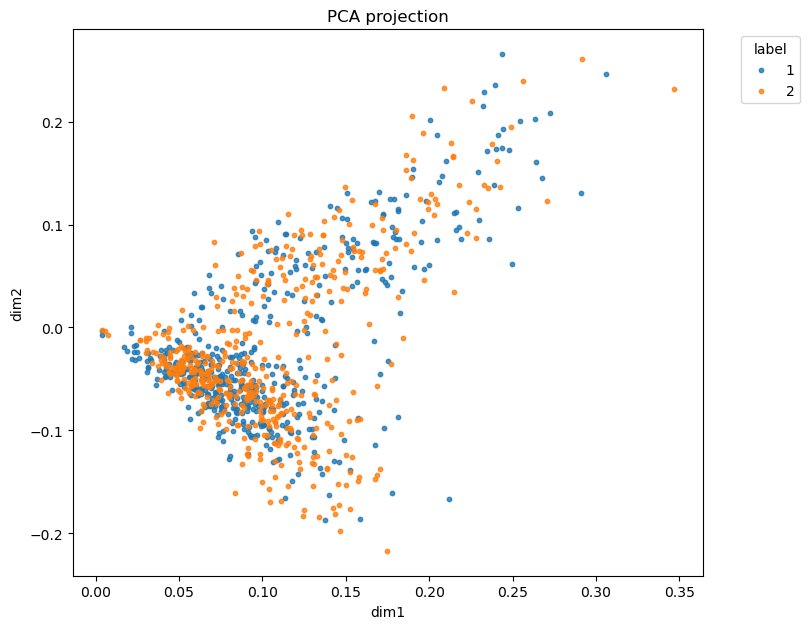

array([[ 0.09310007, -0.05241104],
       [ 0.13001108, -0.09886216],
       [ 0.0930794 , -0.06224365],
       ...,
       [ 0.1078721 ,  0.06668988],
       [ 0.06137685, -0.02710342],
       [ 0.06429021, -0.04825038]])

In [12]:
plot_dimensionality_reduction(tfidf_train, feat_eng_train['review_target'], method='PCA')


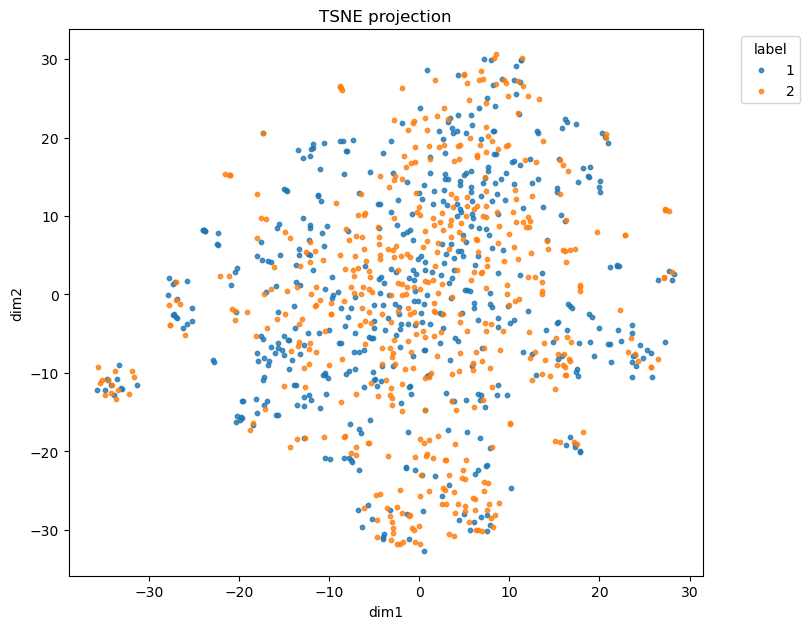

array([[ -1.2793605,  -1.6586918],
       [-13.738694 ,   3.7920287],
       [ -5.7423716, -18.871725 ],
       ...,
       [ 11.461283 ,   9.239615 ],
       [  5.3078294,   0.5775036],
       [-13.600362 , -14.125854 ]], dtype=float32)

In [13]:
plot_dimensionality_reduction(tfidf_train, feat_eng_train['review_target'], method='TSNE')


Save processed data

In [16]:
save(base_path='data/processed', df=feat_eng_train, df_name='feat_eng_train.csv')

Saved dataframe to data/processed/feat_eng_train.csv


{'csv': PosixPath('data/processed/feat_eng_train.csv')}

save the tfidf vectorizer

In [15]:
save(base_path='data/vectorizers', vectorizer=tfidf_train, vectorizer_name='tfidf_train.joblib')

Saved vectorizer to data/vectorizers/tfidf_train.joblib


{'vectorizer': PosixPath('data/vectorizers/tfidf_train.joblib')}